In [ ]:
#!pip install -Uq botorch gpytorch GPy

In [ ]:
import sys
import types

if 'imp' not in sys.modules:
    imp = types.ModuleType('imp')
    sys.modules['imp'] = imp
    # If the library uses specific functions from imp, you might need to mock them:
    imp.load_source = lambda *args: None



In [ ]:
try:
    import climin
except:
    !pip install climin
    import climin

In [1]:
# !rm -rf censored_regressors
# !git clone https://github.com/AndreaKarlova/censored_regressors.git

In [2]:
import tqdm
import math
import torch
import numpy as np
import gpytorch
import pandas as pd
from matplotlib import pyplot as plt

from censored_regressors.distributions.censored_normal import CensoredNormal
from censored_regressors.likelihoods.censored_likelihood_gpytorch import CensoredGaussianLikelihoodAnalytic, CensoredGaussianLikelihood
import censored_regressors.metrics.metrics as cmetrics
from torch import Tensor

## Toy Model

In [3]:
from censored_regressors.utils.data_loader import load_csv_dataset

x, y_true = load_csv_dataset('1D_Groot_Lucas.csv', target_col='y')

In [4]:
# Groot & Lucas experiment
torch.set_default_dtype(torch.float64)

seed_ = 3
np.random.seed(seed_)

def noise_free_target(x):
    y =  6 * x - 2
    return torch.pow(y, 2) * torch.sin(2*y)

domain = torch.linspace(0, 1, 500)

In [5]:
num_quantiles = 11
quantiles = torch.linspace(0, 1, num_quantiles)[:-1]
quantile_values = torch.quantile(torch.Tensor(y_true), quantiles)[:-1]

print(quantiles)
print(quantile_values)

tensor([0.0000, 0.1000, 0.2000, 0.3000, 0.4000, 0.5000, 0.6000, 0.7000, 0.8000,
        0.9000])
tensor([-5.6868, -3.9117, -1.1556, -0.5064, -0.3560, -0.0938,  0.1087,  0.5413,
         1.4420])


182


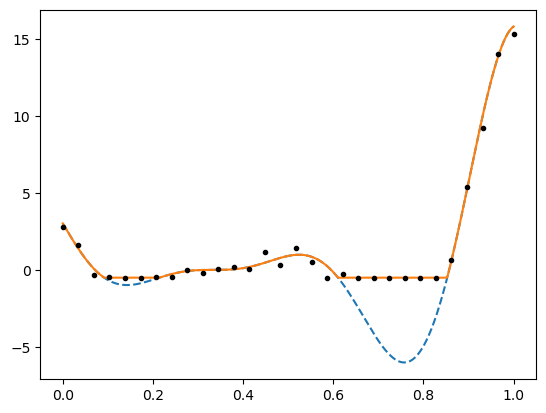

In [6]:
# # # Groot's exact experiment
MIN_VALUE = -0.5064
MAX_VALUE = 1000.

seed_ = 3
np.random.seed(seed_)
y = torch.clamp_max(torch.clamp_min(torch.Tensor(y_true), MIN_VALUE), MAX_VALUE)
censoring_test = np.array([noise_free_target(domain)<= MIN_VALUE]) * -1
print(-censoring_test.sum())

plt.plot(domain, noise_free_target(domain), '--');
plt.plot(domain, torch.clamp_max(torch.clamp_min(noise_free_target(domain), MIN_VALUE), MAX_VALUE), '-');
plt.plot(x, y, 'k.');

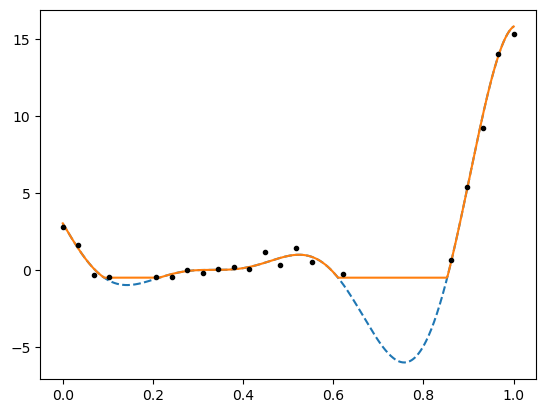

In [7]:
y_uncensored = y[y > MIN_VALUE]
x_uncensored = x[y > MIN_VALUE]

domain = torch.linspace(0., 1., 500)
plt.plot(domain, noise_free_target(domain), '--');
plt.plot(domain, torch.clamp_max(torch.clamp_min(noise_free_target(domain), MIN_VALUE), MAX_VALUE), '-');
plt.plot(x_uncensored, y_uncensored, 'k.')

# Variational Inference

In [8]:
from censored_regressors.models.models_gpytorch import GPModel, CensoredGP_VI_gpytorch
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import torch.nn.functional as F

raw2transformed = lambda x, bound=0.0: F.softplus(x) + bound

In [9]:
likelihood = CensoredGaussianLikelihoodAnalytic(low=MIN_VALUE, high=MAX_VALUE)
kernel_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=2))
model = GPModel(torch.Tensor(x), torch.Tensor(y), kernel_module=kernel_module, variational_strategy_type='variationalstrategy')
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y.size(0))

model.train()
likelihood.train()

# --- CONFIGURATION ---
training_iter = 3000
warmup_steps = 500
# Cosine decay should last the REST of training
cosine_steps = training_iter - warmup_steps

optimizer = torch.optim.Adam([
    # Group 1: Variational parameters (inducing points, variational mean/chol)
    # These often benefit from a faster learning rate
    {'params': model.variational_strategy.parameters(), 'lr': 0.1},

    # Group 2: Hyperparameters (Lengthscale, Outputscale, Likelihood noise)
    # These benefit from a slower, more stable learning rate
    {'params': model.covar_module.parameters(), 'lr': 0.01},
    {'params': likelihood.parameters(), 'lr': 0.01},
], lr=0.01) # Default LR fallback

# --- SMARTER SCHEDULER ---
# 1. Warmup: LINEAR increase from small factor to 1.0
scheduler1 = torch.optim.lr_scheduler.LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=warmup_steps
)

# 2. Decay: COSINE decrease from 1.0 down to eta_min over the REST of the epochs
scheduler2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=cosine_steps,
    eta_min=1e-5
)

# 3. Combine: Switch exactly when warmup finishes
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler1, scheduler2],
    milestones=[warmup_steps]
)

# --- TRAINING LOOP ---
print(f"{'Iter':<10} | {'Loss':<10} | {'LR (Var)':<10} | {'LR (Hyp)':<10} | {'LR (Lik)':<10}")
loss_model = list()
loss_lik = list()
loss_kl = list()
loss_atoms = list()
loss_gauss = list()

eta_path = [raw2transformed(model.covar_module.raw_outputscale.detach())]
sigma_path = [raw2transformed(likelihood.noise.raw_noise.detach()[0])]
ls_path = [raw2transformed(model.covar_module.base_kernel.raw_lengthscale.detach()[0][0])]
lr_path = []

print('lenghtscale, outputscale, lik noise')
print(ls_path[0], eta_path[0], sigma_path[0])

loop = tqdm.tqdm(range(training_iter))
for i in loop:
    optimizer.zero_grad()
    y_model = model(torch.Tensor(x))
    loss = -mll(y_model, torch.Tensor(y))
    loss.backward()
    optimizer.step()
    scheduler.step()

    # Logging
    if i % 100 == 0:
        # Get LR for both groups to monitor them
        lr_var = optimizer.param_groups[0]['lr']
        lr_hyp = optimizer.param_groups[1]['lr']
        lr_lik = optimizer.param_groups[2]['lr']
        tqdm.tqdm.write(f"{i+1:<10} | {loss.item():.4f}     | {lr_var:.2e}     | {lr_hyp:.2e}  {lr_lik:.2e}")

    loop.set_description(f"Loss: {loss.item():.4f}")
    loss_model.append(loss.item())
    loss_kl.append(model.variational_strategy.kl_divergence().sum().item())
    eta_path.append(raw2transformed(model.covar_module.raw_outputscale.detach()))
    ls_path.append(raw2transformed(model.covar_module.base_kernel.raw_lengthscale.detach()[0][0]))
    exp_probs_lik = likelihood._expected_log_prob_terms(y.squeeze(-1), y_model)
    loss_gauss.append(exp_probs_lik['normal_part'].mean().item())
    loss_atoms.append(exp_probs_lik['upper_censored_part'].mean().item() + exp_probs_lik['lower_censored_part'].mean().item())
    sigma_path.append(raw2transformed(likelihood.noise.raw_noise.detach()[0]))

print('training done, loss: {}'.format(loss.item()))
print(ls_path[-1],  eta_path[-1], sigma_path[-1])
model.eval()
likelihood.eval()

with gpytorch.settings.num_likelihood_samples(1000):
    f_preds = model(domain)

    f_mean = f_preds.loc
    f_var = f_preds.variance
    f_covar = f_preds.covariance_matrix

Iter       | Loss       | LR (Var)   | LR (Hyp)   | LR (Lik)  
lenghtscale, outputscale, lik noise
tensor(0.6931) tensor(0.6931) tensor(0.9999)


Loss: 9.9417:   0%|          | 2/3000 [00:00<02:38, 18.89it/s] 

1          | 10.6775     | 1.02e-02     | 1.02e-03  1.02e-03


Loss: 6.2044:   4%|▍         | 116/3000 [00:01<00:21, 135.21it/s]

101        | 6.7177     | 2.82e-02     | 2.82e-03  2.82e-03


...

2801       | 1.7659     | 1.57e-03     | 1.65e-04  1.65e-04


Loss: 1.7655:  97%|█████████▋| 2918/3000 [00:23<00:00, 131.16it/s]

2901       | 1.7656     | 3.96e-04     | 4.86e-05  4.86e-05


Loss: 1.7655: 100%|██████████| 3000/3000 [00:23<00:00, 125.93it/s]


training done, loss: 1.7654667482854445
tensor(0.1281) tensor(7.1821) tensor(1.0224)


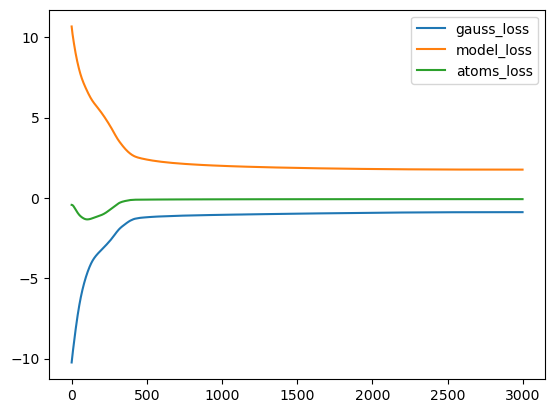

In [10]:
plt.plot(loss_gauss, label='gauss_loss')
plt.plot(loss_model, label='model_loss')
plt.plot(loss_atoms, label='atoms_loss')
plt.legend()

In [11]:
plt.style.use("ggplot")

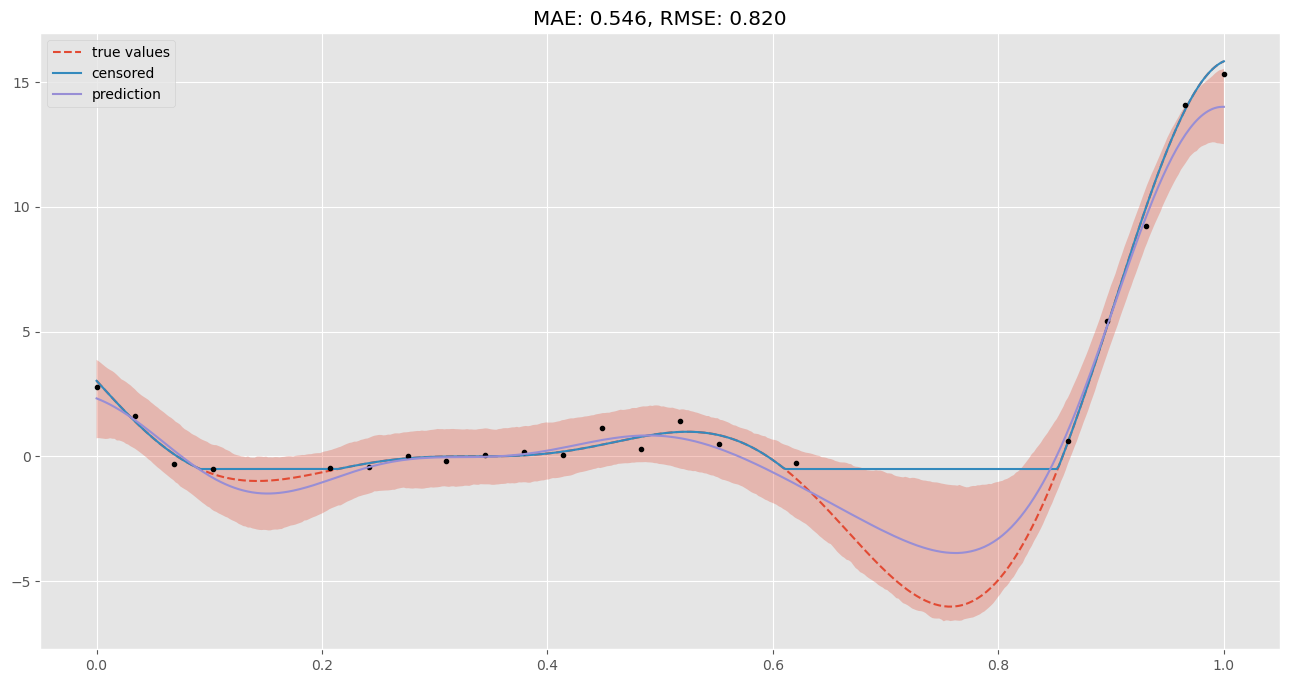

In [12]:
f_samples = f_preds.sample(sample_shape=torch.Size((1000,)))
f_vi_mean = np.mean(f_samples.numpy(), axis=0)
f_vi_025 = np.quantile(a=f_samples.numpy(), q=0.025, axis=0).reshape(-1,)
f_vi_975 = np.quantile(a=f_samples.numpy(), q=0.975, axis=0).reshape(-1,)

plt.figure(figsize=(16,8))
plt.fill_between(domain, f_vi_025, f_vi_975, alpha=0.3)
plt.plot(domain, noise_free_target(domain), '--', label='true values');
plt.plot(domain, torch.clamp_max(torch.clamp_min(noise_free_target(domain), MIN_VALUE), MAX_VALUE), '-', label='censored');
plt.plot(x_uncensored, y_uncensored, 'k.')
plt.plot(domain, f_vi_mean, label='prediction')
plt.title('MAE: {:.3f}, RMSE: {:.3f}'.format(mean_absolute_error(noise_free_target(domain), f_vi_mean), root_mean_squared_error(noise_free_target(domain), f_vi_mean)))
plt.legend();

In [13]:
def predict_gpytorch(model, likelihood, test_data):
    model.eval()
    likelihood.eval()
    
    # FIX: Use as_tensor to handle both numpy arrays and existing tensors
    # We also cast to the same dtype/device as the model parameters to avoid type mismatches
    # (e.g. if model is Double/Float64, inputs must be too)
    if isinstance(test_data, torch.Tensor):
        X_test_torch = test_data
    else:
        X_test_torch = torch.as_tensor(test_data)
        
    # Ensure input matches model type (Float vs Double) and Device (CPU vs GPU)
    # This is safer than just wrapping it
    param_example = next(model.parameters())
    X_test_torch = X_test_torch.to(device=param_example.device, dtype=param_example.dtype)

    with torch.no_grad(), gpytorch.settings.num_likelihood_samples(1000):
        f_preds_dist = model(X_test_torch)
        
        # Sample from the latent distribution
        f_samples = f_preds_dist.sample(sample_shape=torch.Size((1000,)))
        
        # Permute: (Samples, N) -> (N, Samples)
        f_samples = f_samples.permute(1, 0).cpu().numpy()

        f_mean = np.mean(f_samples, axis=1).reshape(-1, 1)
        f_025 = np.quantile(f_samples, 0.025, axis=1).reshape(-1, 1)
        f_975 = np.quantile(f_samples, 0.975, axis=1).reshape(-1, 1)

    return {'f_mean': f_mean, 'f_025': f_025, 'f_975': f_975}

pred_vi = predict_gpytorch(model, likelihood, domain)

In [14]:
metrics_vi = cmetrics.evaluate_censored_metrics(
    model=model,
    X=domain,
    y_pred_mu=pred_vi['f_mean'],
    y_true_cens=torch.clamp_max(torch.clamp_min(noise_free_target(domain), MIN_VALUE), MAX_VALUE),
    gp_lower=pred_vi['f_025'],             # Lower bound
    gp_upper=pred_vi['f_975'],             # Upper bound
    censoring=censoring_test,
    censoring_pred=np.array([noise_free_target(domain) <= MIN_VALUE]) * -1, # Your pred logic
    y_true=noise_free_target(domain),      # Ground truth (if available)
    likelihood=likelihood                  # Passed as keyword argument!
)

print(metrics_vi)

{'nlpd': 0.8578350297740935, 'hinge_mae': 0.5060045880364992, 'coverage': 0.976, 'region_accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'jaccard': 1.0}


# Expectation Propagation

In [15]:
import GPy
from censored_regressors.models.censored_model_gpy import GPCensoredRegression
from censored_regressors.likelihoods.censored_likelihood_gpy import CensoredGaussian

In [16]:
censoring = np.array([y <= MIN_VALUE]) * -1
censoring.sum()

-9

In [17]:
kernel = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
gp = GPCensoredRegression(X=x.reshape(-1, 1), Y=y.reshape(-1, 1),
                          censoring=censoring.reshape(-1), kernel=kernel,
                          likelihood=CensoredGaussian(censoring=censoring, variance=0.1))

defaulting to <censored_regressors.latent_inference.ep_gpy.EPCensored object at 0x135c84da0> for latent function inference


In [28]:
gp.optimize(optimizer="BFGS", max_iters=1000, messages=False)

In [29]:
f_ep_samples = gp.posterior_samples_f(X=domain.numpy().reshape(-1,1), size=10000)
f_ep_mean = np.mean(f_ep_samples, axis=2)
f_ep_025 = np.quantile(a=f_ep_samples, q=0.025, axis=2).reshape(-1,)
f_ep_975 = np.quantile(a=f_ep_samples, q=0.975, axis=2).reshape(-1,)

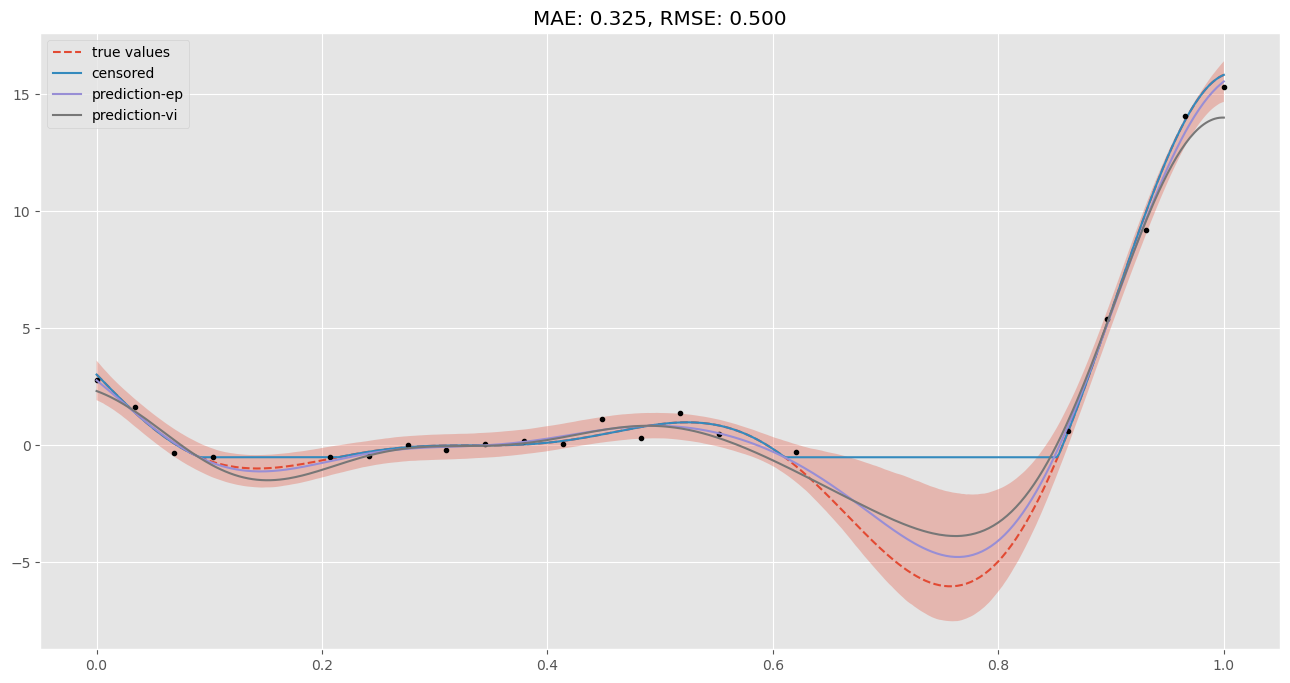

In [30]:
plt.figure(figsize=(16,8))
plt.fill_between(domain, f_ep_025, f_ep_975, alpha=0.3)
plt.plot(domain, noise_free_target(domain), '--', label='true values');
plt.plot(domain, torch.clamp_max(torch.clamp_min(noise_free_target(domain), MIN_VALUE), MAX_VALUE), '-', label='censored');
plt.plot(x_uncensored, y_uncensored, 'k.')
plt.plot(domain, f_ep_mean, label='prediction-ep')
plt.title('MAE: {:.3f}, RMSE: {:.3f}'.format(mean_absolute_error(noise_free_target(domain), f_ep_mean), root_mean_squared_error(noise_free_target(domain), f_ep_mean)))
plt.plot(domain, f_vi_mean, label='prediction-vi')
plt.legend();

In [31]:
metrics_ep = cmetrics.evaluate_censored_metrics(
    model=model,
    X=domain,
    y_pred_mu=f_ep_mean,
    y_true_cens=torch.clamp_max(torch.clamp_min(noise_free_target(domain), MIN_VALUE), MAX_VALUE),
    gp_lower=f_ep_025,             # Lower bound
    gp_upper=f_ep_975,             # Upper bound
    censoring=censoring_test,
    censoring_pred=np.array([noise_free_target(domain) <= MIN_VALUE]) * -1, # Your pred logic
    y_true=noise_free_target(domain),      # Ground truth (if available)
)

print(metrics_ep)

{'nlpd': nan, 'hinge_mae': 0.3128696668609839, 'coverage': 1.0, 'region_accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'jaccard': 1.0}


 /Users/bromia/projects/censored_regressors/src/censored_regressors/metrics/metrics.py:58: UserWarning:Likelihood not found for GPyTorch model. NLPD skipped.


# Laplace Approximation

In [22]:
from GPy.inference.latent_function_inference import Laplace

kernel = GPy.kern.RBF(input_dim=1, variance=1., lengthscale=1.)
gp = GPCensoredRegression(X=x.reshape(-1, 1), Y=y.reshape(-1, 1),
                          censoring=censoring.reshape(-1), kernel=kernel,
                          likelihood=CensoredGaussian(censoring=censoring, variance=0.1),
                          inference_method=Laplace())

In [23]:
[gp.optimize(optimizer="BFGS", max_iters=1000, messages=True), gp.optimize(optimizer="BFGS", max_iters=1000, messages=True)]

In [24]:
f_la_samples = gp.posterior_samples_f(X=domain.numpy().reshape(-1,1), size=10000)
f_la_mean = np.mean(f_la_samples, axis=2)
f_la_025 = np.quantile(a=f_la_samples, q=0.025, axis=2).reshape(-1,)
f_la_975 = np.quantile(a=f_la_samples, q=0.975, axis=2).reshape(-1,)

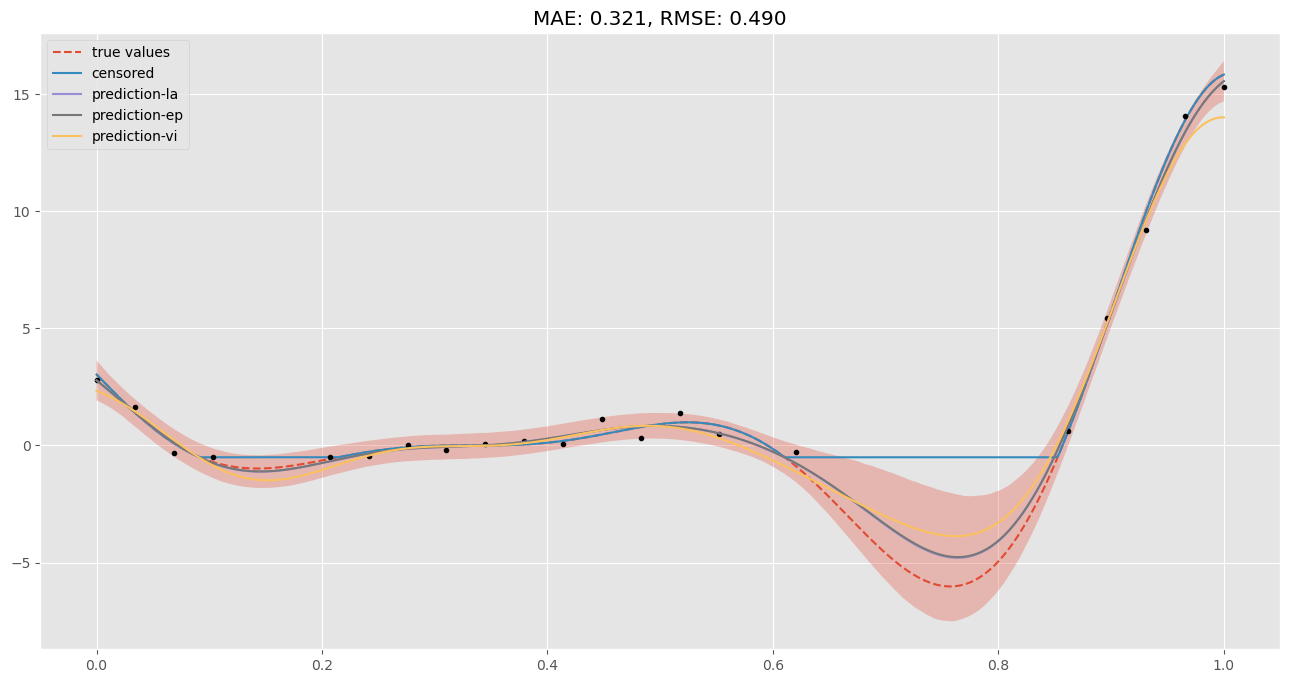

In [32]:
plt.figure(figsize=(16,8))
plt.fill_between(domain, f_la_025, f_la_975, alpha=0.3)
plt.plot(domain, noise_free_target(domain), '--', label='true values');
plt.plot(domain, torch.clamp_max(torch.clamp_min(noise_free_target(domain), MIN_VALUE), MAX_VALUE), '-', label='censored');
plt.plot(x_uncensored, y_uncensored, 'k.')
plt.plot(domain, f_la_mean, label='prediction-la')
plt.plot(domain, f_ep_mean, label='prediction-ep')
plt.plot(domain, f_vi_mean, label='prediction-vi')
plt.title('MAE: {:.3f}, RMSE: {:.3f}'.format(mean_absolute_error(noise_free_target(domain), f_la_mean),
                                             root_mean_squared_error(noise_free_target(domain), f_la_mean)))
plt.legend();

In [26]:
metrics_la = cmetrics.evaluate_censored_metrics(
    model=model,
    X=domain,
    y_pred_mu=f_la_mean,
    y_true_cens=torch.clamp_max(torch.clamp_min(noise_free_target(domain), MIN_VALUE), MAX_VALUE),
    gp_lower=f_la_025,             # Lower bound
    gp_upper=f_la_975,             # Upper bound
    censoring=censoring_test,
    censoring_pred=np.array([noise_free_target(domain) <= MIN_VALUE]) * -1, # Your pred logic
    y_true=noise_free_target(domain),      # Ground truth (if available)
)

print(metrics_la)

{'nlpd': nan, 'hinge_mae': 0.30770225679862745, 'coverage': 1.0, 'region_accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'jaccard': 1.0}


 /Users/bromia/projects/censored_regressors/src/censored_regressors/metrics/metrics.py:58: UserWarning:Likelihood not found for GPyTorch model. NLPD skipped.


# Results

In [33]:
import pandas as pd

res = {"VI - ours": metrics_vi, 'EP': metrics_ep, 'LA': metrics_la}
pd.DataFrame.from_dict(res)

,VI - ours,EP,LA
nlpd,0.857835,NaN,NaN
hinge_mae,0.506005,0.31287,0.307702
coverage,0.976000,1.00000,1.000000
region_accuracy,1.000000,1.00000,1.000000
precision,1.000000,1.00000,1.000000
recall,1.000000,1.00000,1.000000
jaccard,1.000000,1.00000,1.000000
